# Question 1

In [3]:
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import matplotlib.pyplot as plt

def create_phantom(size):
    phantom = shepp_logan_phantom()  # Default is 400x400
    phantom_resized = resize(phantom, (size, size), mode="reflect", anti_aliasing=True)

    return phantom_resized


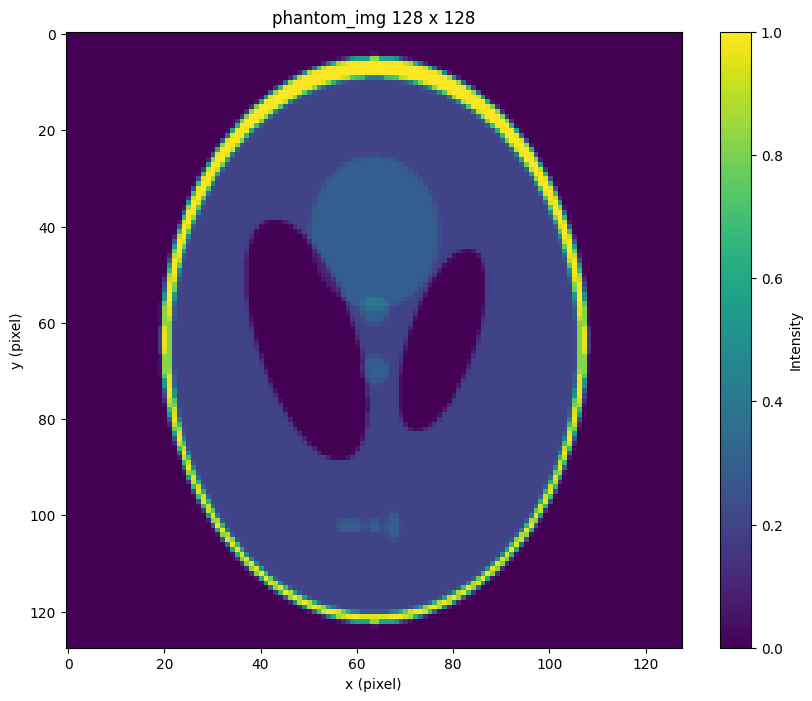

In [6]:
phantom_img = create_phantom(128)
# Plot the input field
plt.figure(figsize=(10, 8))
plt.imshow(phantom_img)
plt.colorbar(label='Intensity')
plt.xlabel('x (pixel)')
plt.ylabel('y (pixel)')
plt.title('phantom_img 128 x 128')
plt.show()

Question 1 a

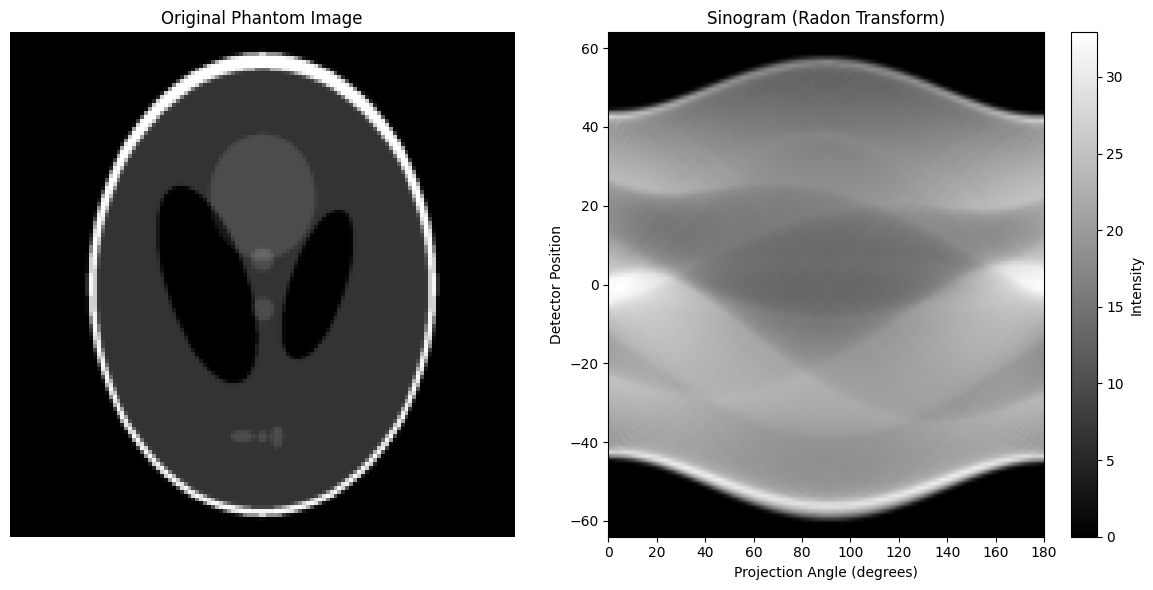

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon
from skimage.io import imread

# Load your phantom image
# Replace 'phantom_img.png' with the path to your image if needed
phantom_img = phantom_img  # Using your existing variable

# Compute Radon transform (projections)
theta = np.linspace(0, 179, 180)  # angles from 0° to 179° in 1° steps
R = radon(phantom_img, theta=theta)

# Plot the original phantom image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(phantom_img, cmap='gray')
plt.title('Original Phantom Image')
plt.axis('off')

# Plot the sinogram
plt.subplot(1, 2, 2)
plt.imshow(R, cmap='gray', aspect='auto', 
           extent=[0, 180, -R.shape[0]//2, R.shape[0]//2])
plt.title('Sinogram (Radon Transform)')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# https://claude.ai/share/0cb5f520-0825-4414-8564-404379011f81

Question 2

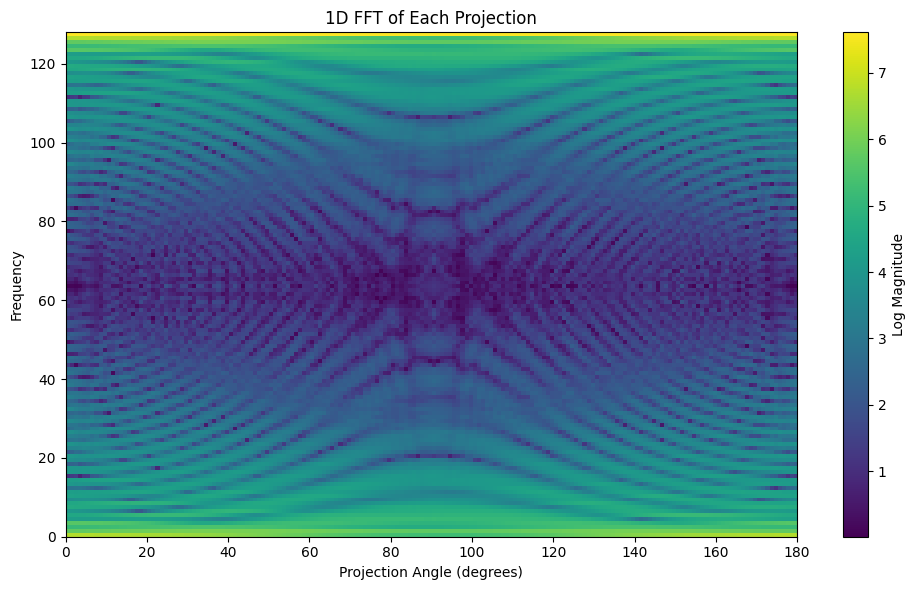

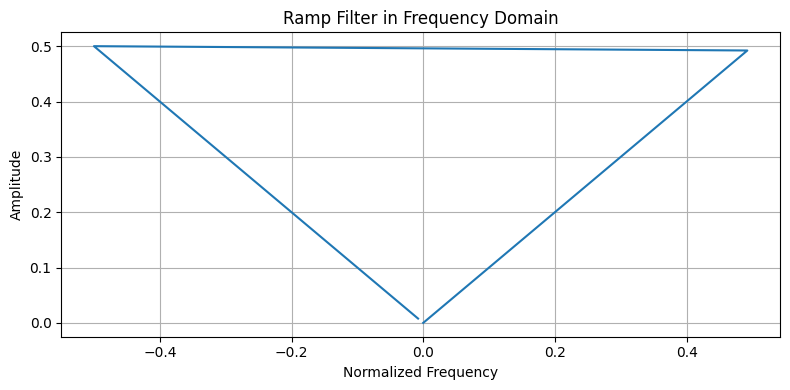

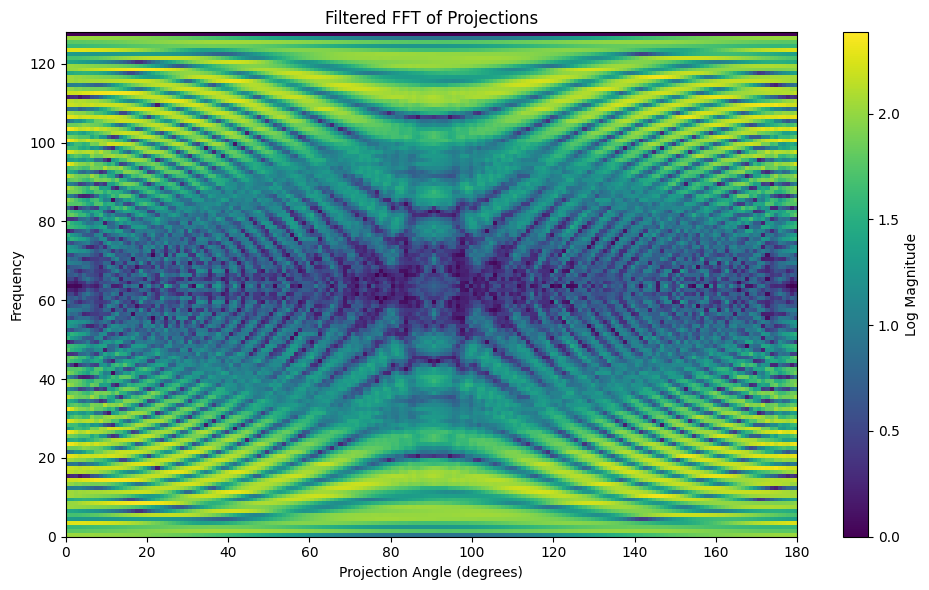

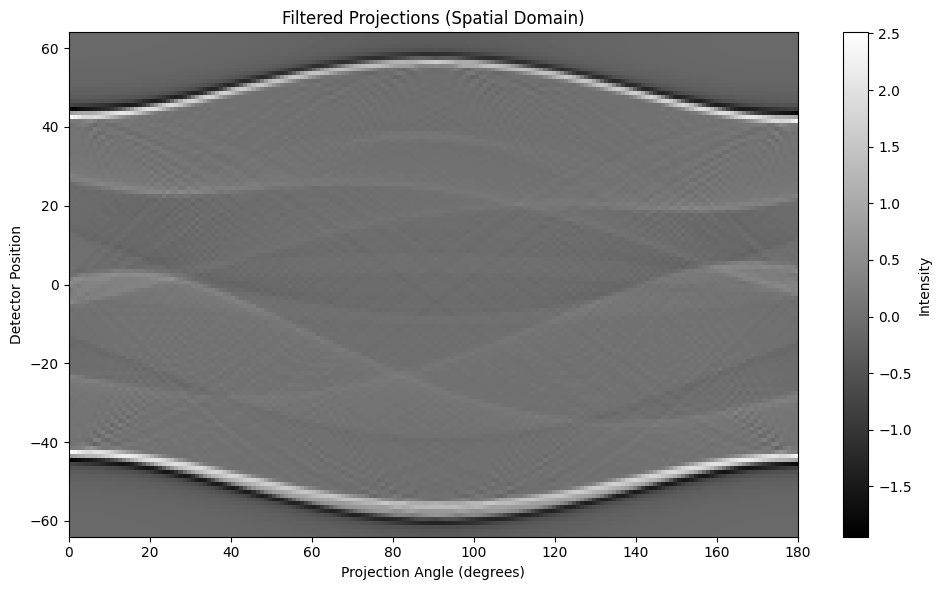

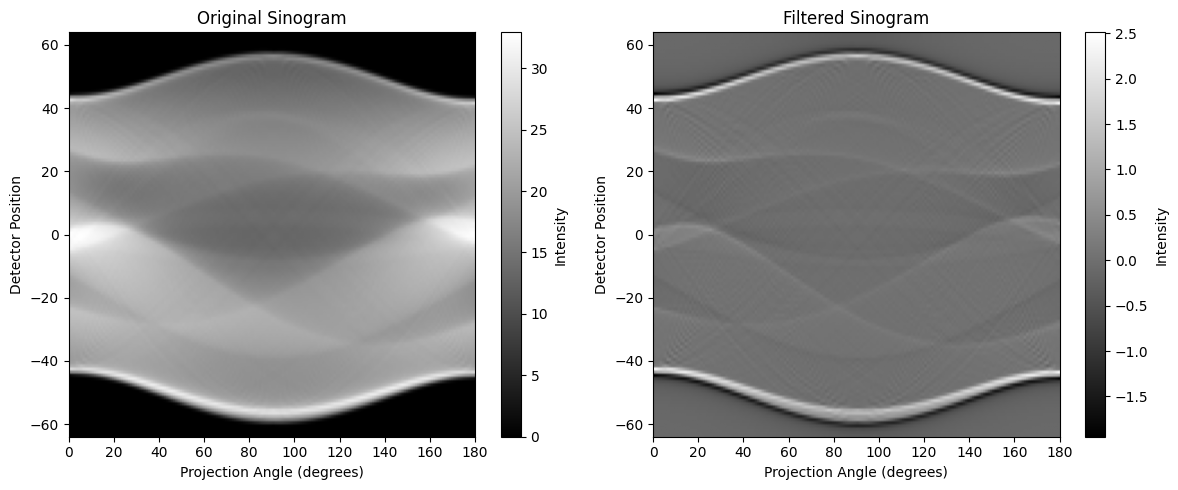

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Compute 1D FFT for each projection (column in the sinogram)
R_fft = np.fft.fft(R, axis=0)

# Plot the magnitude of the FFT result (using log scale for better visualization)
plt.figure(figsize=(10, 6))
plt.imshow(np.log(np.abs(R_fft) + 1), aspect='auto', cmap='viridis',
           extent=[0, 180, 0, R.shape[0]])
plt.colorbar(label='Log Magnitude')
plt.title('1D FFT of Each Projection')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Step 2: Construct the Ramp filter in frequency domain
n = R.shape[0]  # Size of projections
freq = np.fft.fftfreq(n)  # Create frequency array
ramp_filter = np.abs(freq)  # Ramp filter is |f|

# Plot the ramp filter
plt.figure(figsize=(8, 4))
plt.plot(freq, ramp_filter)
plt.title('Ramp Filter in Frequency Domain')
plt.xlabel('Normalized Frequency')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Apply the filter to the FFT (multiply each column by the ramp filter)
filter_2d = ramp_filter.reshape(-1, 1)  # Reshape for broadcasting
filtered_fft = R_fft * filter_2d  # Apply filter to each projection

# Plot the filtered FFT
plt.figure(figsize=(10, 6))
plt.imshow(np.log(np.abs(filtered_fft) + 1), aspect='auto', cmap='viridis',
           extent=[0, 180, 0, R.shape[0]])
plt.colorbar(label='Log Magnitude')
plt.title('Filtered FFT of Projections')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Step 4: Inverse FFT to get filtered projections in spatial domain
filtered_projections = np.real(np.fft.ifft(filtered_fft, axis=0))

# Plot the filtered projections
plt.figure(figsize=(10, 6))
plt.imshow(filtered_projections, aspect='auto', cmap='gray', 
           extent=[0, 180, -filtered_projections.shape[0]//2, filtered_projections.shape[0]//2])
plt.title('Filtered Projections (Spatial Domain)')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Compare with original sinogram
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(R, aspect='auto', cmap='gray', 
           extent=[0, 180, -R.shape[0]//2, R.shape[0]//2])
plt.title('Original Sinogram')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')

plt.subplot(1, 2, 2)
plt.imshow(filtered_projections, aspect='auto', cmap='gray', 
           extent=[0, 180, -filtered_projections.shape[0]//2, filtered_projections.shape[0]//2])
plt.title('Filtered Sinogram')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

Question 3

num_angles 180
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 128)
projection_2d(128, 128)
rotated (128, 1

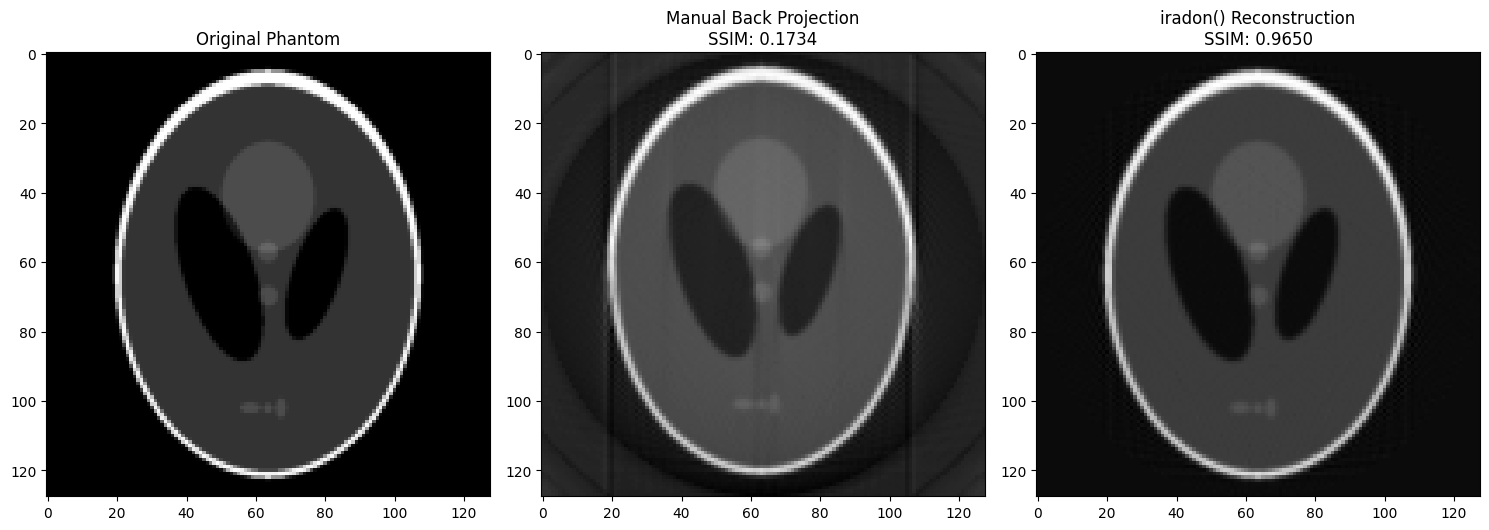

SSIM for manual reconstruction: 0.1734
SSIM for iradon reconstruction: 0.9650


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import iradon
from skimage.metrics import structural_similarity as ssim
import cv2

# Assuming we have:
# - filtered_projections: the filtered sinogram from previous step
# - R: original sinogram
# - phantom_img: original phantom image
# - theta: angles from 0° to 179° in 1° steps

# Get dimensions
img_size = phantom_img.shape[0]  # Assuming square image (128x128)
num_angles = len(theta)  # Should be 180
print(f'num_angles {num_angles}')
# Step 1: Initialize reconstruction grid (blank image)
reconstruction = np.zeros((img_size, img_size)) # (128,128)

# Step 2: Loop through each projection angle
for i, angle in enumerate(theta):
    # Get the filtered projection for this angle
    projection = filtered_projections[:, i]
    
    # Replicate the 1D projection to create a 2D image
    # Each row of the 2D image will be the same projection
    projection_2d = np.tile(projection, (img_size, 1))
    print(f'projection_2d{projection_2d.shape}')
    # Rotate the 2D image by -angle
    # We use order=1 for bilinear interpolation
    # We need to rotate by negative angle because we're back-projecting
    rotated = rotate(projection_2d, -angle, reshape=False, order=1)
    print(f'rotated {rotated.shape}')
    reconstruction += rotated

# Step 3: Normalize by the number of projection angles
reconstruction /= num_angles
rotated_reconstruction = cv2.flip(reconstruction,0)
ssim_manual = ssim(phantom_img, rotated_reconstruction, data_range=phantom_img.max())
# Step 4: Crop to central region if needed
# (This may be necessary due to size differences between radon and our reconstruction)
# center = reconstruction.shape[0] // 2
# half_size = img_size // 2
# reconstruction_cropped = reconstruction[center-half_size:center+half_size, 
#                                         center-half_size:center+half_size]

# Step 5: Compare with direct iradon implementation
# Use filter='ramp' to match our manual implementation
iradon_reconstruction = iradon(R, theta=theta, filter_name='ramp')

print(iradon_reconstruction.shape)
# Calculate SSIM for reconstructions
ssim_iradon = ssim(phantom_img, iradon_reconstruction, data_range=phantom_img.max())

# Plot results
plt.figure(figsize=(15, 5))

# Original phantom
plt.subplot(1, 3, 1)
plt.imshow(phantom_img, cmap='gray')
plt.title('Original Phantom')
plt.axis('on')

# Our reconstruction
plt.subplot(1, 3, 2)
plt.imshow(rotated_reconstruction, cmap='gray')
plt.title(f'Manual Back Projection\nSSIM: {ssim_manual:.4f}')
plt.axis('on')

# iradon reconstruction
plt.subplot(1, 3, 3)
plt.imshow(iradon_reconstruction, cmap='gray')
plt.title(f'iradon() Reconstruction\nSSIM: {ssim_iradon:.4f}')
plt.axis('on')

plt.tight_layout()
plt.show()

# Print SSIM values
print(f"SSIM for manual reconstruction: {ssim_manual:.4f}")
print(f"SSIM for iradon reconstruction: {ssim_iradon:.4f}")

Question 4a

num_angles 180
(128, 128)


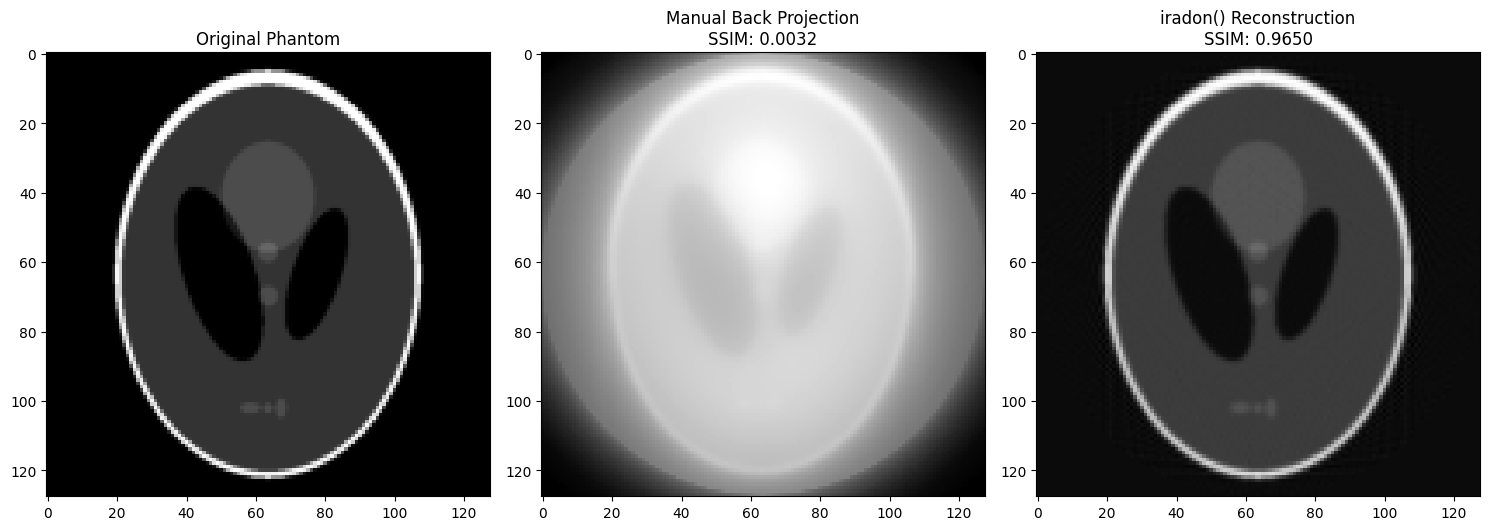

SSIM for manual reconstruction: 0.0032
SSIM for iradon reconstruction: 0.9650


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import iradon
from skimage.metrics import structural_similarity as ssim

# Assuming we have:
# - filtered_projections: the filtered sinogram from previous step
# - R: original sinogram
# - phantom_img: original phantom image
# - theta: angles from 0° to 179° in 1° steps

# Get dimensions
img_size = phantom_img.shape[0]  # Assuming square image (128x128)
num_angles = len(theta)  # Should be 180
print(f'num_angles {num_angles}')
# Step 1: Initialize reconstruction grid (blank image)
reconstruction = np.zeros((img_size, img_size)) # (128,128)

# Step 2: Loop through each projection angle
for i, angle in enumerate(theta):
    # Get the filtered projection for this angle
    projection = R[:, i]
    
    # Replicate the 1D projection to create a 2D image
    # Each row of the 2D image will be the same projection
    projection_2d = np.tile(projection, (img_size, 1))
    # print(f'projection_2d{projection_2d.shape}')
    # Rotate the 2D image by -angle
    # We use order=1 for bilinear interpolation
    # We need to rotate by negative angle because we're back-projecting
    rotated = rotate(projection_2d, -angle, reshape=False, order=1)
    # print(f'rotated {rotated.shape}')
    reconstruction += rotated

# Step 3: Normalize by the number of projection angles
reconstruction /= num_angles
rotated_reconstruction = cv2.flip(reconstruction, 0)
ssim_manual = ssim(phantom_img, rotated_reconstruction, data_range=phantom_img.max())
# Step 4: Crop to central region if needed
# (This may be necessary due to size differences between radon and our reconstruction)
# center = reconstruction.shape[0] // 2
# half_size = img_size // 2
# reconstruction_cropped = reconstruction[center-half_size:center+half_size, 
#                                         center-half_size:center+half_size]

# Step 5: Compare with direct iradon implementation
# Use filter='ramp' to match our manual implementation
iradon_reconstruction = iradon(R, theta=theta, filter_name='ramp')

print(iradon_reconstruction.shape)
# Calculate SSIM for reconstructions
ssim_iradon = ssim(phantom_img, iradon_reconstruction, data_range=phantom_img.max())

# Plot results
plt.figure(figsize=(15, 5))

# Original phantom
plt.subplot(1, 3, 1)
plt.imshow(phantom_img, cmap='gray')
plt.title('Original Phantom')
plt.axis('on')

# Our reconstruction
plt.subplot(1, 3, 2)
plt.imshow(rotated_reconstruction, cmap='gray')
plt.title(f'Manual Back Projection\nSSIM: {ssim_manual:.4f}')
plt.axis('on')

# iradon reconstruction
plt.subplot(1, 3, 3)
plt.imshow(iradon_reconstruction, cmap='gray')
plt.title(f'iradon() Reconstruction\nSSIM: {ssim_iradon:.4f}')
plt.axis('on')

plt.tight_layout()
plt.show()

# Print SSIM values
print(f"SSIM for manual reconstruction: {ssim_manual:.4f}")
print(f"SSIM for iradon reconstruction: {ssim_iradon:.4f}")

Question 4b

num_angles 180
iradon reconstruction shape: (128, 128)


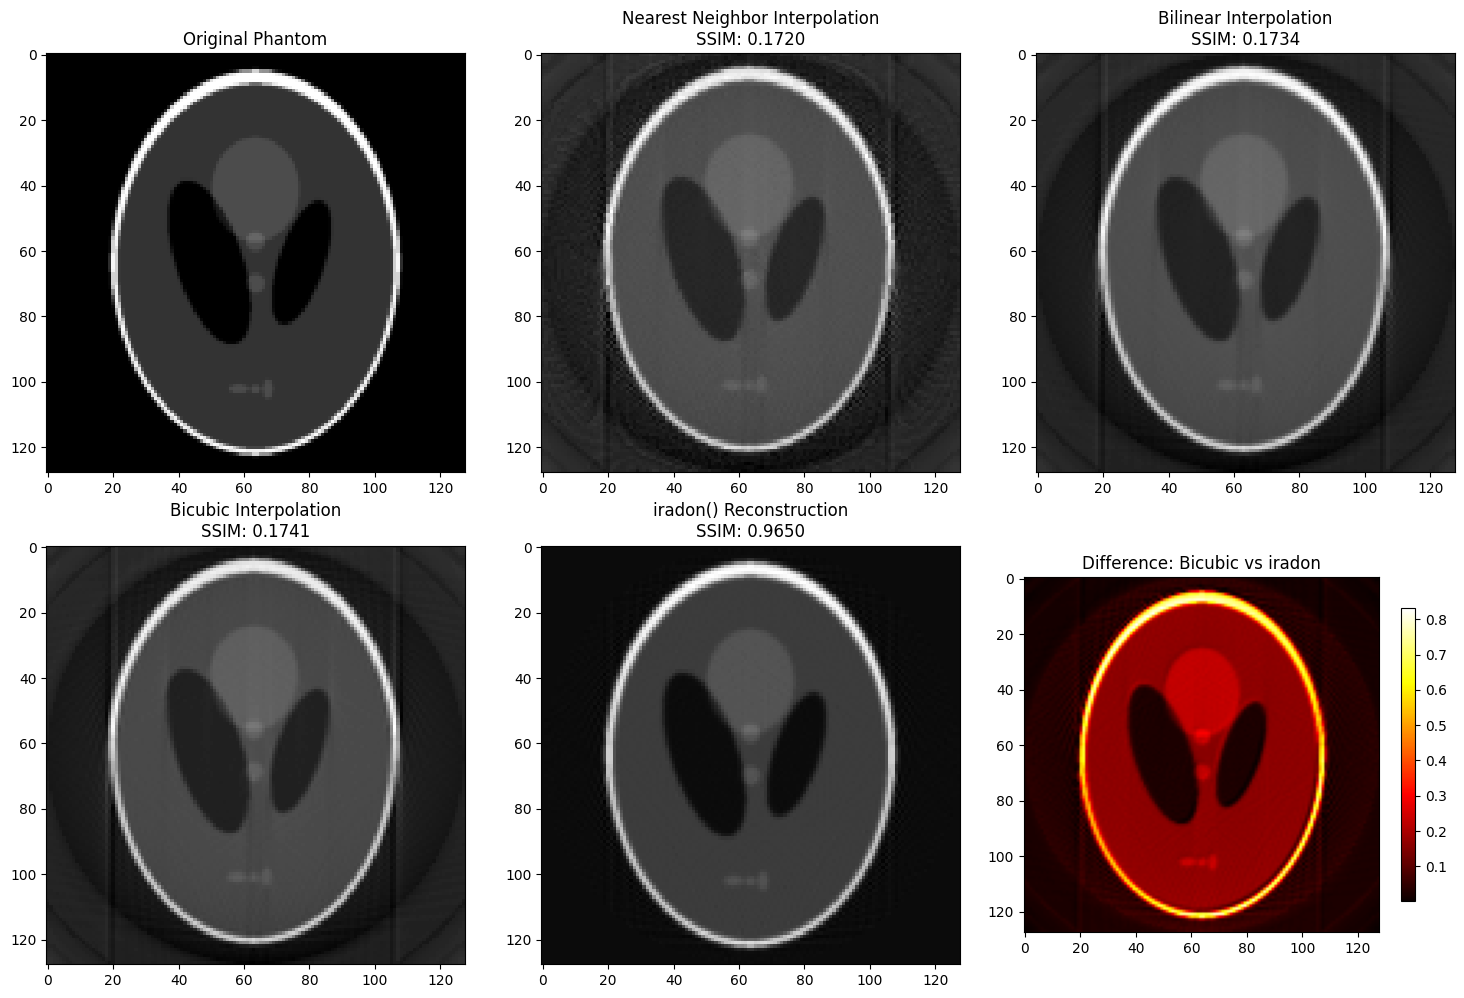

SSIM for Nearest Neighbor interpolation: 0.1720
SSIM for Bilinear interpolation: 0.1734
SSIM for Bicubic interpolation: 0.1741
SSIM for iradon reconstruction: 0.9650


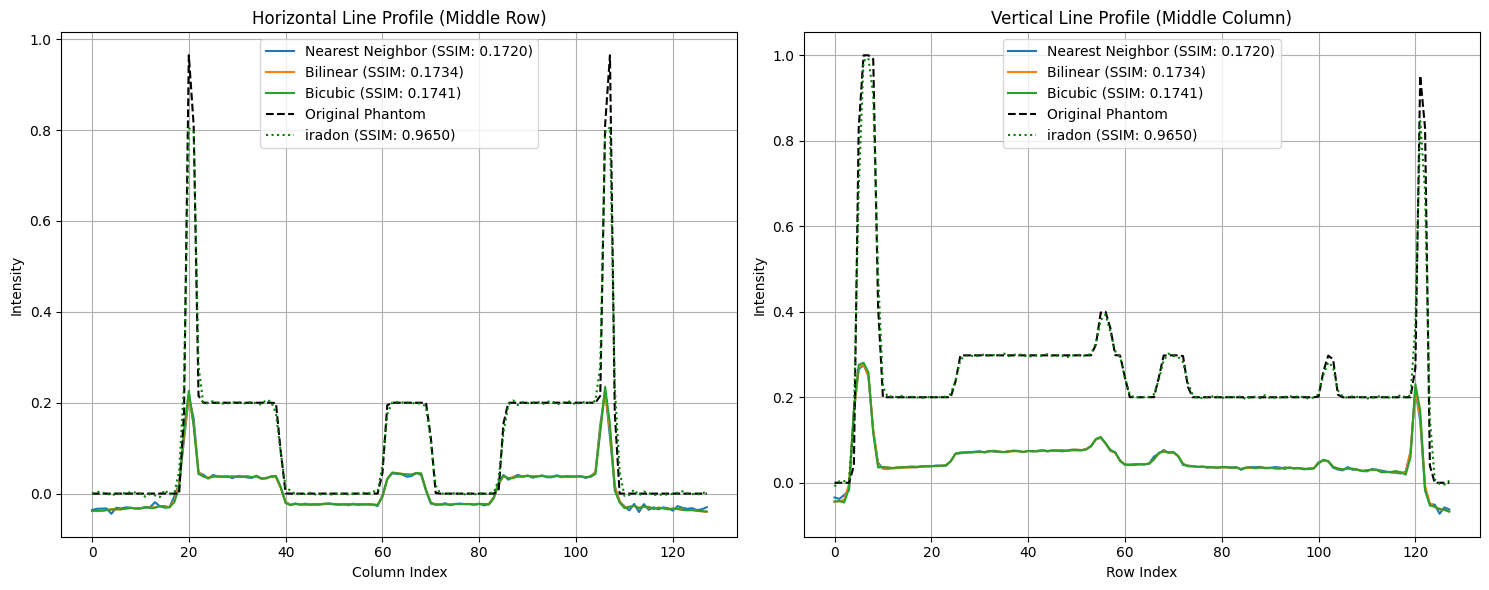

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import iradon
from skimage.metrics import structural_similarity as ssim
import cv2

# Assuming we have:
# - filtered_projections: the filtered sinogram from previous step
# - R: original sinogram
# - phantom_img: original phantom image
# - theta: angles from 0° to 179° in 1° steps

# Get dimensions
img_size = phantom_img.shape[0]  # Assuming square image (128x128)
num_angles = len(theta)  # Should be 180
print(f'num_angles {num_angles}')

# Define interpolation orders to compare
interpolation_orders = [0, 1, 3]  # Nearest neighbor, Bilinear, Bicubic
order_names = ['Nearest Neighbor', 'Bilinear', 'Bicubic']
reconstructions = []

# Loop through each interpolation order
for order in interpolation_orders:
    # Initialize reconstruction grid (blank image)
    reconstruction = np.zeros((img_size, img_size))  # (128,128)
    
    # Loop through each projection angle
    for i, angle in enumerate(theta):
        # Get the filtered projection for this angle
        projection = filtered_projections[:, i]
        
        # Replicate the 1D projection to create a 2D image
        # Each row of the 2D image will be the same projection
        projection_2d = np.tile(projection, (img_size, 1))
        
        # Rotate the 2D image by -angle with the current interpolation order
        rotated = rotate(projection_2d, -angle, reshape=False, order=order)
        
        # Add to reconstruction
        reconstruction += rotated
    
    # Normalize by the number of projection angles
    reconstruction /= num_angles
    
    # Flip the reconstruction vertically (as in the original code)
    rotated_reconstruction = cv2.flip(reconstruction, 0)
    
    # Store the result
    reconstructions.append(rotated_reconstruction)

# Calculate SSIM for each reconstruction method
ssim_values = [ssim(phantom_img, recon, data_range=phantom_img.max()) for recon in reconstructions]

# Step 5: Compare with direct iradon implementation
# Use filter='ramp' to match our manual implementation
iradon_reconstruction = iradon(R, theta=theta, filter_name='ramp')
print(f"iradon reconstruction shape: {iradon_reconstruction.shape}")

# Calculate SSIM for iradon reconstruction
ssim_iradon = ssim(phantom_img, iradon_reconstruction, data_range=phantom_img.max())

# Plot results
plt.figure(figsize=(15, 10))

# Original phantom
plt.subplot(2, 3, 1)
plt.imshow(phantom_img, cmap='gray')
plt.title('Original Phantom')
plt.axis('on')

# Plot our reconstructions with different interpolation methods
for i, (recon, order_name, ssim_val) in enumerate(zip(reconstructions, order_names, ssim_values)):
    plt.subplot(2, 3, i+2)
    plt.imshow(recon, cmap='gray')
    plt.title(f'{order_name} Interpolation\nSSIM: {ssim_val:.4f}')
    plt.axis('on')

# iradon reconstruction
plt.subplot(2, 3, 5)
plt.imshow(iradon_reconstruction, cmap='gray')
plt.title(f'iradon() Reconstruction\nSSIM: {ssim_iradon:.4f}')
plt.axis('on')

# Add a difference image between best manual method and iradon
best_method_idx = np.argmax(ssim_values)
diff_image = np.abs(reconstructions[best_method_idx] - iradon_reconstruction)
plt.subplot(2, 3, 6)
plt.imshow(diff_image, cmap='hot')
plt.title(f'Difference: {order_names[best_method_idx]} vs iradon')
plt.colorbar(shrink=0.7)
plt.axis('on')

plt.tight_layout()
plt.show()

# Print SSIM values
for i, (order_name, ssim_val) in enumerate(zip(order_names, ssim_values)):
    print(f"SSIM for {order_name} interpolation: {ssim_val:.4f}")
print(f"SSIM for iradon reconstruction: {ssim_iradon:.4f}")

# Plot line profiles for comparison
plt.figure(figsize=(15, 6))

# Horizontal line profile (middle row)
row = img_size // 2
plt.subplot(1, 2, 1)
for i, (recon, order_name) in enumerate(zip(reconstructions, order_names)):
    plt.plot(recon[row, :], label=f'{order_name} (SSIM: {ssim_values[i]:.4f})')
plt.plot(phantom_img[row, :], 'k--', label='Original Phantom')
plt.plot(iradon_reconstruction[row, :], 'g:', label=f'iradon (SSIM: {ssim_iradon:.4f})')
plt.title('Horizontal Line Profile (Middle Row)')
plt.xlabel('Column Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)

# Vertical line profile (middle column)
col = img_size // 2
plt.subplot(1, 2, 2)
for i, (recon, order_name) in enumerate(zip(reconstructions, order_names)):
    plt.plot(recon[:, col], label=f'{order_name} (SSIM: {ssim_values[i]:.4f})')
plt.plot(phantom_img[:, col], 'k--', label='Original Phantom')
plt.plot(iradon_reconstruction[:, col], 'g:', label=f'iradon (SSIM: {ssim_iradon:.4f})')
plt.title('Vertical Line Profile (Middle Column)')
plt.xlabel('Row Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Question 4c

Original number of angles: 180
Number of angles with 10° increments: 18


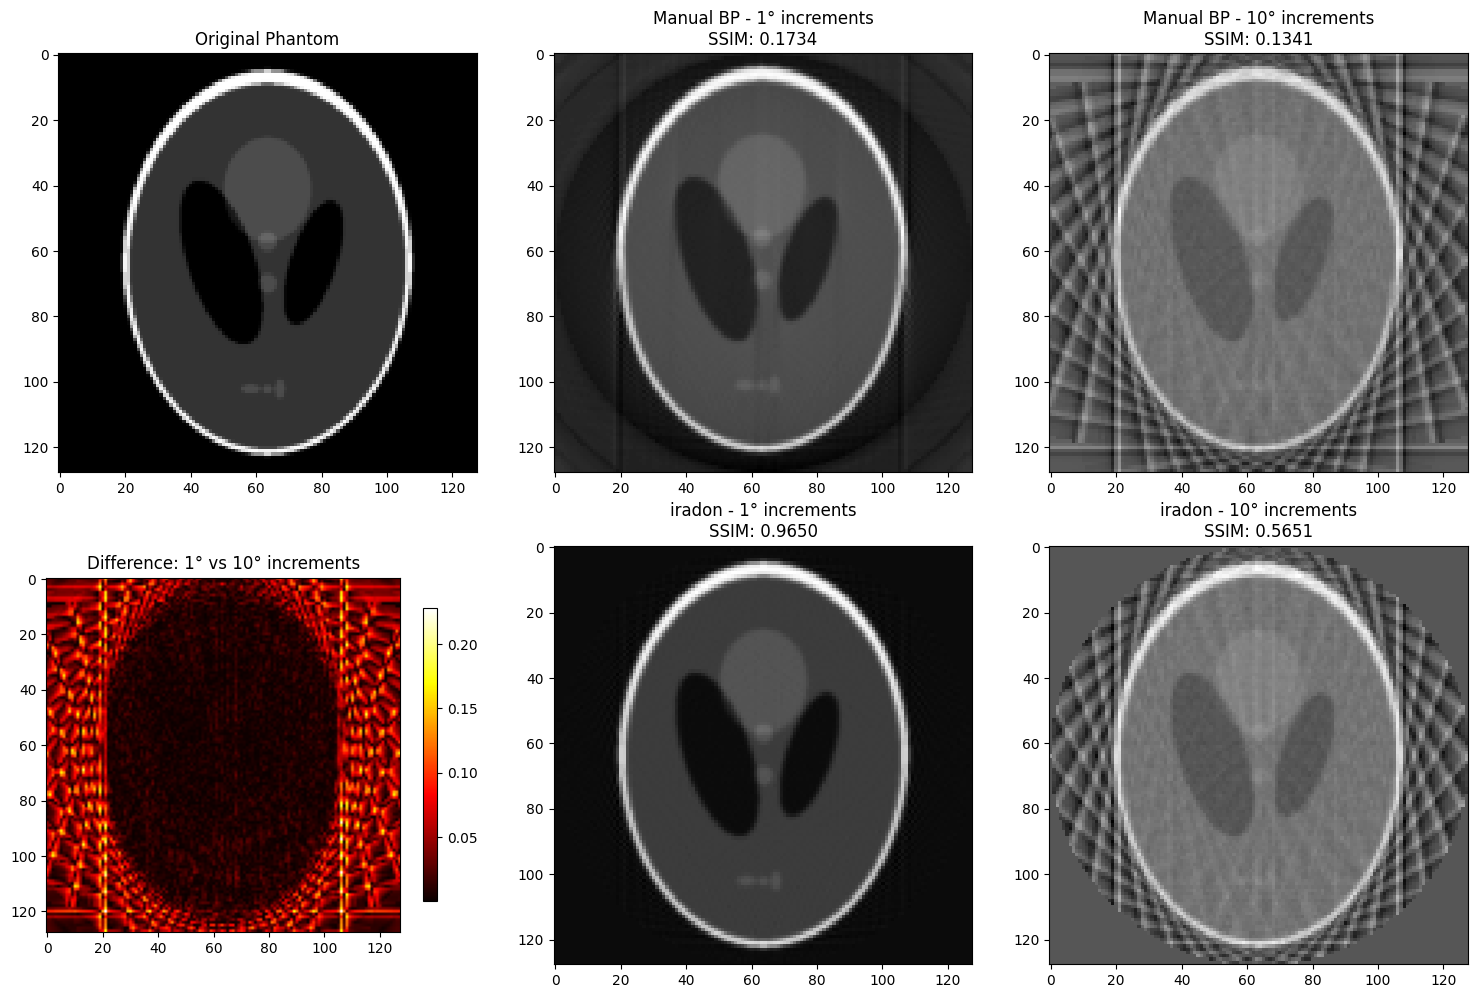

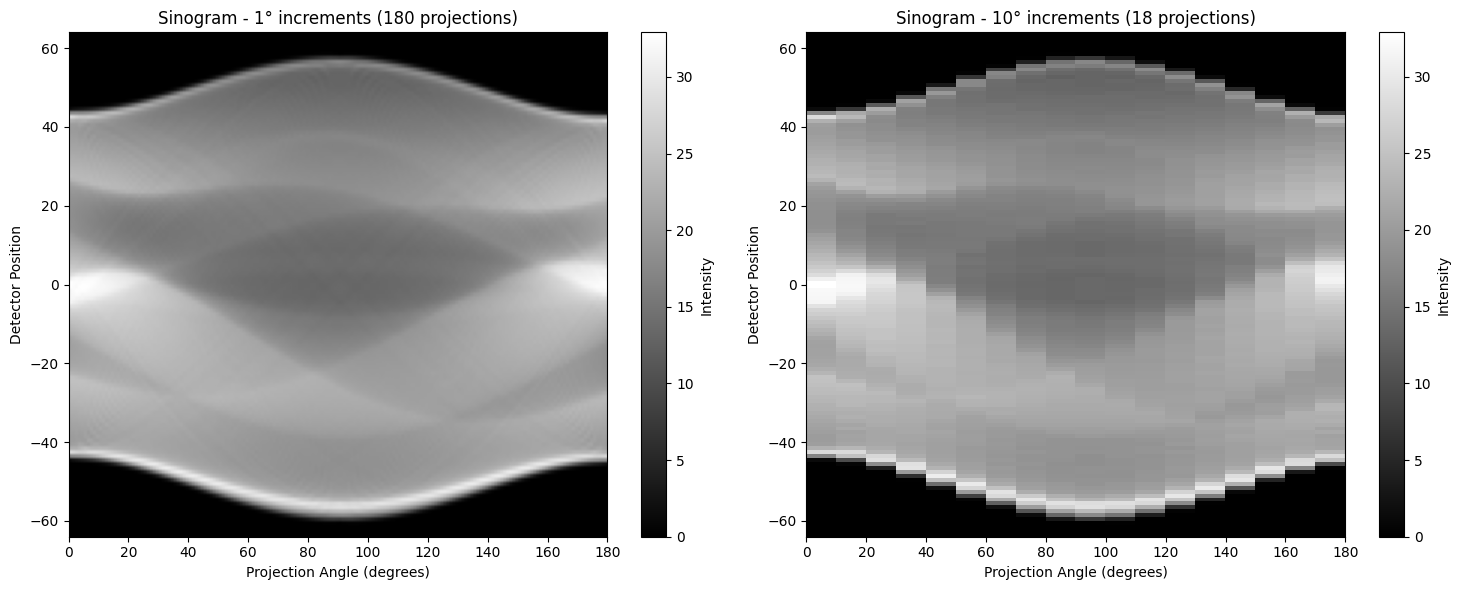

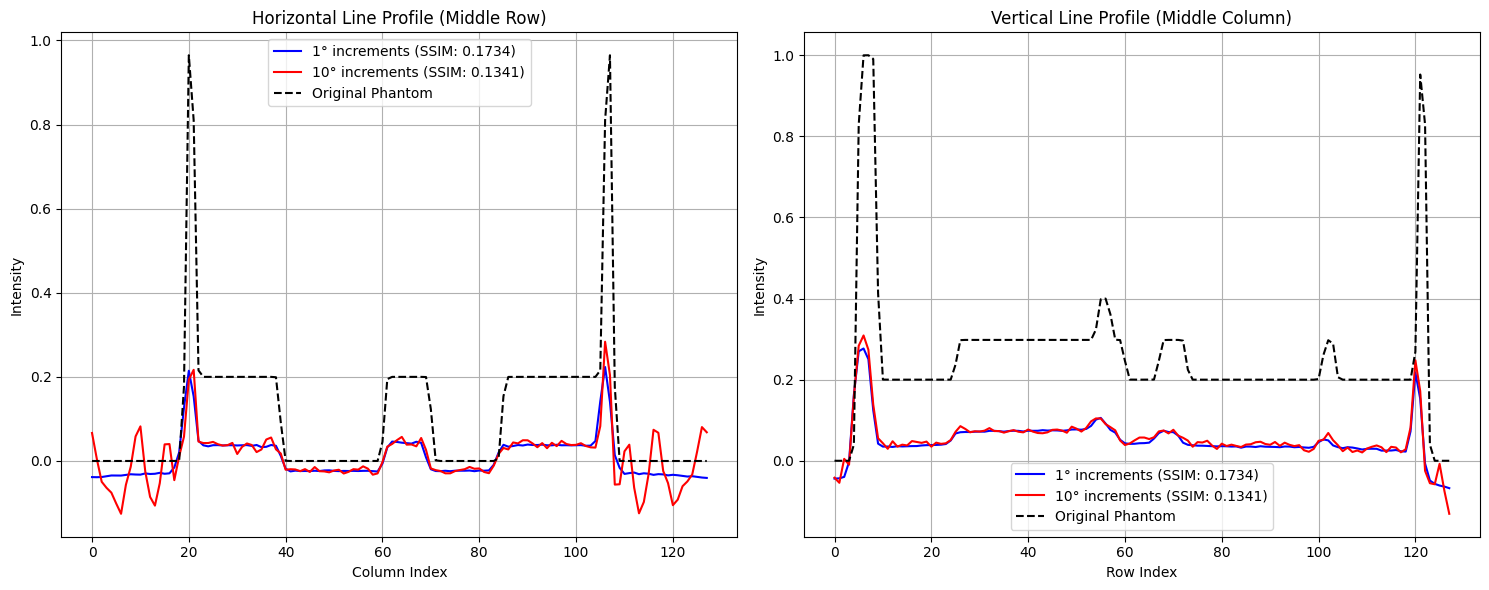

SSIM for manual reconstruction - 1° increments: 0.1734
SSIM for manual reconstruction - 10° increments: 0.1341
SSIM for iradon reconstruction - 1° increments: 0.9650
SSIM for iradon reconstruction - 10° increments: 0.5651


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import iradon, radon
from skimage.metrics import structural_similarity as ssim
import cv2

# Assuming we have:
# - filtered_projections: the filtered sinogram from previous step (1° increments)
# - R: original sinogram (1° increments)
# - phantom_img: original phantom image
# - theta: angles from 0° to 179° in 1° steps

# Get dimensions
img_size = phantom_img.shape[0]  # Assuming square image (128x128)
num_angles = len(theta)  # Should be 180
print(f'Original number of angles: {num_angles}')

# Create 10° increments array
theta_10deg = np.arange(0, 180, 10)
print(f'Number of angles with 10° increments: {len(theta_10deg)}')

# Extract corresponding projections for 10° increments
# Find indices that are closest to our 10° increments
indices_10deg = [np.argmin(np.abs(theta - angle)) for angle in theta_10deg]
filtered_projections_10deg = filtered_projections[:, indices_10deg]
R_10deg = R[:, indices_10deg]

# Define reconstruction functions to reuse code
def reconstruct_from_projections(proj_data, angles, order=1):
    reconstruction = np.zeros((img_size, img_size))
    
    for i, angle in enumerate(angles):
        # Get the filtered projection for this angle
        projection = proj_data[:, i]
        
        # Replicate the 1D projection to create a 2D image
        projection_2d = np.tile(projection, (img_size, 1))
        
        # Rotate the 2D image by -angle with the specified interpolation order
        rotated = rotate(projection_2d, -angle, reshape=False, order=order)
        
        # Add to reconstruction
        reconstruction += rotated
    
    # Normalize by the number of projection angles
    reconstruction /= len(angles)
    
    # Flip the reconstruction vertically (as in the original code)
    return cv2.flip(reconstruction, 0)

# Create reconstructions with 1° and 10° increments
recon_1deg = reconstruct_from_projections(filtered_projections, theta)
recon_10deg = reconstruct_from_projections(filtered_projections_10deg, theta_10deg)

# Also create iradon reconstructions for comparison
iradon_1deg = iradon(R, theta=theta, filter_name='ramp')
iradon_10deg = iradon(R_10deg, theta=theta_10deg, filter_name='ramp')

# Calculate SSIM values
ssim_1deg = ssim(phantom_img, recon_1deg, data_range=phantom_img.max())
ssim_10deg = ssim(phantom_img, recon_10deg, data_range=phantom_img.max())
ssim_iradon_1deg = ssim(phantom_img, iradon_1deg, data_range=phantom_img.max())
ssim_iradon_10deg = ssim(phantom_img, iradon_10deg, data_range=phantom_img.max())

# Plot results
plt.figure(figsize=(15, 10))

# Original phantom
plt.subplot(2, 3, 1)
plt.imshow(phantom_img, cmap='gray')
plt.title('Original Phantom')
plt.axis('on')

# Our reconstructions with different angular increments
plt.subplot(2, 3, 2)
plt.imshow(recon_1deg, cmap='gray')
plt.title(f'Manual BP - 1° increments\nSSIM: {ssim_1deg:.4f}')
plt.axis('on')

plt.subplot(2, 3, 3)
plt.imshow(recon_10deg, cmap='gray')
plt.title(f'Manual BP - 10° increments\nSSIM: {ssim_10deg:.4f}')
plt.axis('on')

# iradon reconstructions
plt.subplot(2, 3, 5)
plt.imshow(iradon_1deg, cmap='gray')
plt.title(f'iradon - 1° increments\nSSIM: {ssim_iradon_1deg:.4f}')
plt.axis('on')

plt.subplot(2, 3, 6)
plt.imshow(iradon_10deg, cmap='gray')
plt.title(f'iradon - 10° increments\nSSIM: {ssim_iradon_10deg:.4f}')
plt.axis('on')

# Difference image between 1° and 10° manual reconstructions
diff_image = np.abs(recon_1deg - recon_10deg)
plt.subplot(2, 3, 4)
plt.imshow(diff_image, cmap='hot')
plt.title('Difference: 1° vs 10° increments')
plt.colorbar(shrink=0.7)
plt.axis('on')

plt.tight_layout()
plt.show()

# Plot sinograms for comparison
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(R, cmap='gray', aspect='auto', extent=[0, 180, -R.shape[0]//2, R.shape[0]//2])
plt.title('Sinogram - 1° increments (180 projections)')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')

plt.subplot(1, 2, 2)
plt.imshow(R_10deg, cmap='gray', aspect='auto', extent=[0, 180, -R_10deg.shape[0]//2, R_10deg.shape[0]//2])
plt.title('Sinogram - 10° increments (18 projections)')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Plot line profiles for comparison
plt.figure(figsize=(15, 6))

# Horizontal line profile (middle row)
row = img_size // 2
plt.subplot(1, 2, 1)
plt.plot(recon_1deg[row, :], 'b-', label=f'1° increments (SSIM: {ssim_1deg:.4f})')
plt.plot(recon_10deg[row, :], 'r-', label=f'10° increments (SSIM: {ssim_10deg:.4f})')
plt.plot(phantom_img[row, :], 'k--', label='Original Phantom')
plt.title('Horizontal Line Profile (Middle Row)')
plt.xlabel('Column Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)

# Vertical line profile (middle column)
col = img_size // 2
plt.subplot(1, 2, 2)
plt.plot(recon_1deg[:, col], 'b-', label=f'1° increments (SSIM: {ssim_1deg:.4f})')
plt.plot(recon_10deg[:, col], 'r-', label=f'10° increments (SSIM: {ssim_10deg:.4f})')
plt.plot(phantom_img[:, col], 'k--', label='Original Phantom')
plt.title('Vertical Line Profile (Middle Column)')
plt.xlabel('Row Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print SSIM values
print(f"SSIM for manual reconstruction - 1° increments: {ssim_1deg:.4f}")
print(f"SSIM for manual reconstruction - 10° increments: {ssim_10deg:.4f}")
print(f"SSIM for iradon reconstruction - 1° increments: {ssim_iradon_1deg:.4f}")
print(f"SSIM for iradon reconstruction - 10° increments: {ssim_iradon_10deg:.4f}")

Question 4d

Original number of angles (0° to 179°): 180
Number of angles (20° to 60°): 41


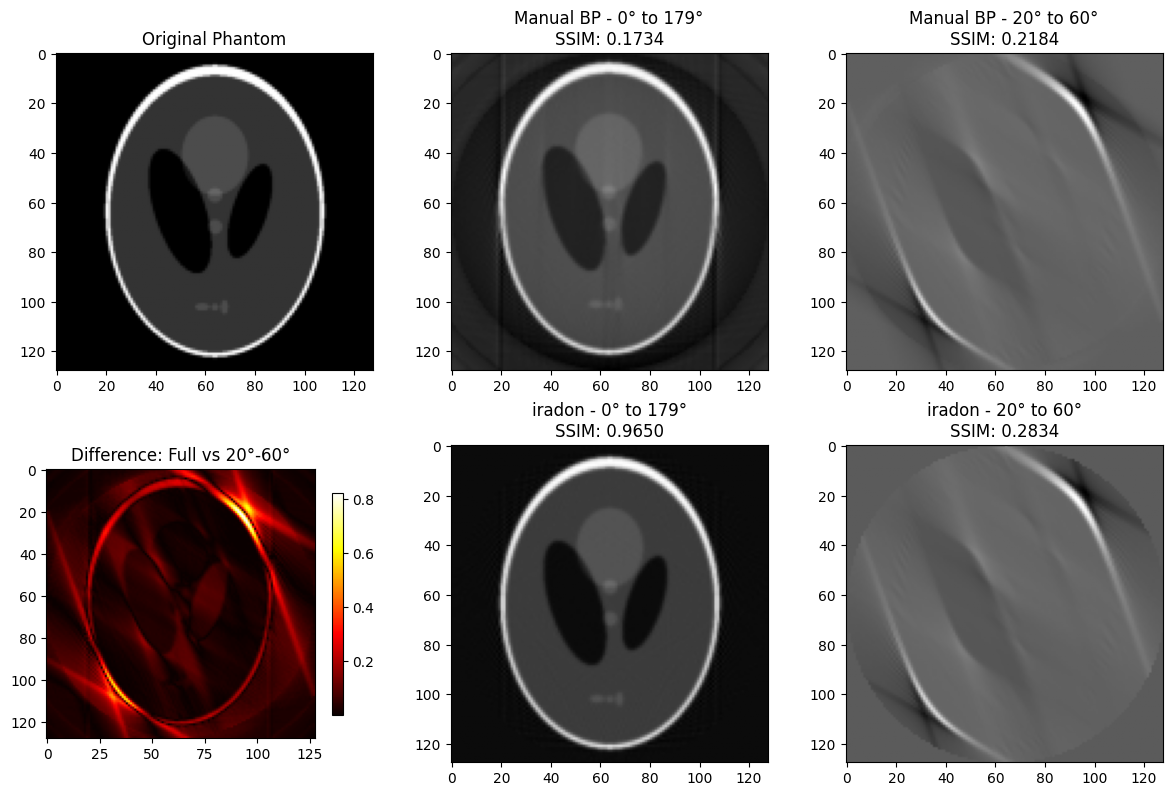

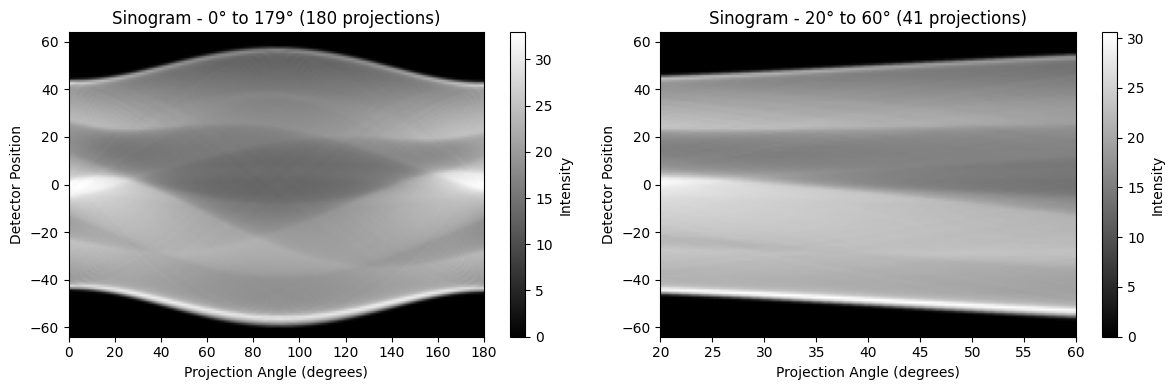

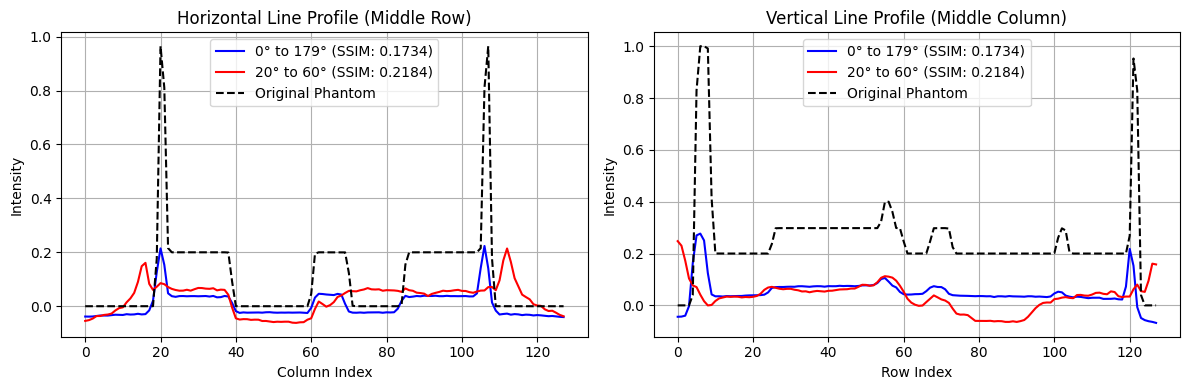

SSIM for manual reconstruction - 0° to 179°: 0.1734
SSIM for manual reconstruction - 20° to 60°: 0.2184
SSIM for iradon reconstruction - 0° to 179°: 0.9650
SSIM for iradon reconstruction - 20° to 60°: 0.2834


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import iradon
from skimage.metrics import structural_similarity as ssim
import cv2

# Assuming we have:
# - filtered_projections: the filtered sinogram
# - R: original sinogram
# - phantom_img: original phantom image
# - theta: angles from 0° to 179° in 1° steps

# Get dimensions
img_size = phantom_img.shape[0]  # Assuming square image (128x128)
theta_full = theta  # Original angles (0° to 179°)
num_angles_full = len(theta_full)
print(f'Original number of angles (0° to 179°): {num_angles_full}')

# Create angle array for 20° to 60° in 1° increments
theta_20_60 = np.arange(20, 61, 1)
print(f'Number of angles (20° to 60°): {len(theta_20_60)}')

# Extract corresponding projections for 20° to 60°
indices_20_60 = [np.argmin(np.abs(theta_full - angle)) for angle in theta_20_60]
filtered_projections_20_60 = filtered_projections[:, indices_20_60]
R_20_60 = R[:, indices_20_60]

# Define reconstruction function
def reconstruct_from_projections(proj_data, angles, order=1):
    reconstruction = np.zeros((img_size, img_size))
    
    for i, angle in enumerate(angles):
        projection = proj_data[:, i]
        projection_2d = np.tile(projection, (img_size, 1))
        rotated = rotate(projection_2d, -angle, reshape=False, order=order)
        reconstruction += rotated
    
    reconstruction /= len(angles)
    return cv2.flip(reconstruction, 0)

# Create reconstructions
recon_full = reconstruct_from_projections(filtered_projections, theta_full)
recon_20_60 = reconstruct_from_projections(filtered_projections_20_60, theta_20_60)

# Create iradon reconstructions
iradon_full = iradon(R, theta=theta_full, filter_name='ramp')
iradon_20_60 = iradon(R_20_60, theta=theta_20_60, filter_name='ramp')

# Calculate SSIM values
ssim_full = ssim(phantom_img, recon_full, data_range=phantom_img.max())
ssim_20_60 = ssim(phantom_img, recon_20_60, data_range=phantom_img.max())
ssim_iradon_full = ssim(phantom_img, iradon_full, data_range=phantom_img.max())
ssim_iradon_20_60 = ssim(phantom_img, iradon_20_60, data_range=phantom_img.max())

# Plot results
plt.figure(figsize=(12, 8))

# Original phantom
plt.subplot(2, 3, 1)
plt.imshow(phantom_img, cmap='gray')
plt.title('Original Phantom')
plt.axis('on')

# Manual reconstructions
plt.subplot(2, 3, 2)
plt.imshow(recon_full, cmap='gray')
plt.title(f'Manual BP - 0° to 179°\nSSIM: {ssim_full:.4f}')
plt.axis('on')

plt.subplot(2, 3, 3)
plt.imshow(recon_20_60, cmap='gray')
plt.title(f'Manual BP - 20° to 60°\nSSIM: {ssim_20_60:.4f}')
plt.axis('on')

# iradon reconstructions
plt.subplot(2, 3, 5)
plt.imshow(iradon_full, cmap='gray')
plt.title(f'iradon - 0° to 179°\nSSIM: {ssim_iradon_full:.4f}')
plt.axis('on')

plt.subplot(2, 3, 6)
plt.imshow(iradon_20_60, cmap='gray')
plt.title(f'iradon - 20° to 60°\nSSIM: {ssim_iradon_20_60:.4f}')
plt.axis('on')

# Difference image
diff_image = np.abs(recon_full - recon_20_60)
plt.subplot(2, 3, 4)
plt.imshow(diff_image, cmap='hot')
plt.title('Difference: Full vs 20°-60°')
plt.colorbar(shrink=0.7)
plt.axis('on')

plt.tight_layout()
plt.show()

# Plot sinograms
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(R, cmap='gray', aspect='auto', extent=[0, 180, -R.shape[0]//2, R.shape[0]//2])
plt.title('Sinogram - 0° to 179° (180 projections)')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')

plt.subplot(1, 2, 2)
plt.imshow(R_20_60, cmap='gray', aspect='auto', extent=[20, 60, -R_20_60.shape[0]//2, R_20_60.shape[0]//2])
plt.title('Sinogram - 20° to 60° (41 projections)')
plt.xlabel('Projection Angle (degrees)')
plt.ylabel('Detector Position')
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# Plot line profiles
plt.figure(figsize=(12, 4))

# Horizontal line profile
row = img_size // 2
plt.subplot(1, 2, 1)
plt.plot(recon_full[row, :], 'b-', label=f'0° to 179° (SSIM: {ssim_full:.4f})')
plt.plot(recon_20_60[row, :], 'r-', label=f'20° to 60° (SSIM: {ssim_20_60:.4f})')
plt.plot(phantom_img[row, :], 'k--', label='Original Phantom')
plt.title('Horizontal Line Profile (Middle Row)')
plt.xlabel('Column Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)

# Vertical line profile
col = img_size // 2
plt.subplot(1, 2, 2)
plt.plot(recon_full[:, col], 'b-', label=f'0° to 179° (SSIM: {ssim_full:.4f})')
plt.plot(recon_20_60[:, col], 'r-', label=f'20° to 60° (SSIM: {ssim_20_60:.4f})')
plt.plot(phantom_img[:, col], 'k--', label='Original Phantom')
plt.title('Vertical Line Profile (Middle Column)')
plt.xlabel('Row Index')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print SSIM values
print(f"SSIM for manual reconstruction - 0° to 179°: {ssim_full:.4f}")
print(f"SSIM for manual reconstruction - 20° to 60°: {ssim_20_60:.4f}")
print(f"SSIM for iradon reconstruction - 0° to 179°: {ssim_iradon_full:.4f}")
print(f"SSIM for iradon reconstruction - 20° to 60°: {ssim_iradon_20_60:.4f}")